#Imports:

In [43]:
from collections import Counter
from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from datasets import load_dataset

nltk.download("stopwords", quiet=True) 

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

[nltk_data] Error loading stopwords: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>


##Load Dataset:

In [44]:
# Load dataset directly from local disk (No token or network required)
train_set = load_dataset("parquet", data_files={"train": "data/wildguardtrain.parquet"})
test_set = load_dataset("parquet", data_files={"test": "data/wildguardtest.parquet"})


In [45]:
train_df = train_set['train'].to_pandas()
test_df = test_set['test'].to_pandas()


LABEL_MAP = {
    ("unharmful", False): 0,
    ("unharmful", True): 1,
    ("harmful", False): 2,
    ("harmful", True): 3,
}

TARGET_NAMES = {
    0: "Benign_Vanilla",
    1: "Benign_Adversarial",
    2: "Harmful_Vanilla",
    3: "Harmful_Adversarial",
}

def safe_bool(value):
    if isinstance(value, bool):
        return value
    if isinstance(value, (int, float)):
        return bool(value)
    return str(value).strip().lower() in {"true", "1", "yes", "y", "t"}

def process_target_labels(df):
    before = len(df)

    # Drop rows missing required label columns
    df_clean = df.dropna(subset=['prompt_harm_label', 'adversarial']).copy()

    # Create 4-class target
    df_clean['target'] = [
        LABEL_MAP.get((str(harm).strip().lower(), safe_bool(adv)))
        for harm, adv in zip(
            df_clean['prompt_harm_label'],
            df_clean['adversarial']
        )
    ]

    # Remove rows where mapping failed
    df_clean = df_clean.dropna(subset=['target'])

    # Convert target to int
    df_clean['target'] = df_clean['target'].astype(int)

    # Add readable class name
    df_clean['target_name'] = df_clean['target'].map(TARGET_NAMES)

    print(f"Rows kept: {len(df_clean)}/{before}")

    # Keep only required columns
    return df_clean[['prompt', 'target', 'target_name']]

train_df = process_target_labels(train_df)
test_df = process_target_labels(test_df)

print(train_df['target_name'].value_counts())
print(test_df['target_name'].value_counts())

Rows kept: 86759/86759
Rows kept: 1699/1725
target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


#EDA:


In [46]:
print("Train Shape: ", train_df.shape)
print("Test Shape: ", test_df.shape)

print("Train Columns: ", train_df.columns.tolist())
print("Test Columns: ", test_df.columns.tolist())

Train Shape:  (86759, 3)
Test Shape:  (1699, 3)
Train Columns:  ['prompt', 'target', 'target_name']
Test Columns:  ['prompt', 'target', 'target_name']


In [47]:
print("Train Data:")
train_df.info()

print("\n" + "=" * 30)

print("Test Data:")
test_df.info()

Train Data:
<class 'pandas.DataFrame'>
RangeIndex: 86759 entries, 0 to 86758
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       86759 non-null  str  
 1   target       86759 non-null  int64
 2   target_name  86759 non-null  str  
dtypes: int64(1), str(2)
memory usage: 44.8 MB

Test Data:
<class 'pandas.DataFrame'>
Index: 1699 entries, 0 to 1724
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   prompt       1699 non-null   str  
 1   target       1699 non-null   int64
 2   target_name  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 877.1 KB


In [48]:
#Missing Values in train and test data
print(train_df.isnull().sum())

print("\n" + "=" * 30)

print(test_df.isnull().sum())

prompt         0
target         0
target_name    0
dtype: int64

prompt         0
target         0
target_name    0
dtype: int64


In [49]:
#Empty prompts in train and test data
train_empty = train_df[train_df['prompt'].str.strip() == '']
print("Empty prompts in train data: ", train_empty.shape[0])

test_empty = test_df[test_df['prompt'].str.strip() == '']
print("Empty prompts in test data: ", test_empty.shape[0])

Empty prompts in train data:  14
Empty prompts in test data:  0


In [50]:
#Short prompts in train and test data
print("Short prompts in train data: ")
display(train_df[['prompt', 'target_name']].assign(word_count=train_df['prompt'].str.split().str.len()).sort_values("word_count").head(20))

Short prompts in train data: 


,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [51]:
#Duplicate prompts in train and test data
print("Duplicate prompts in train data: ", 
      train_df["prompt"].duplicated().sum())


print("Duplicate prompts in test data: ", 
      test_df["prompt"].duplicated().sum())

Duplicate prompts in train data:  38907
Duplicate prompts in test data:  0


In [52]:
#Class distribution in train and test data
train_class_counts = train_df['target_name'].value_counts()
print(train_class_counts)

test_class_counts = test_df['target_name'].value_counts()
print(test_class_counts)

target_name
Harmful_Vanilla        25649
Harmful_Adversarial    20567
Benign_Adversarial     20389
Benign_Vanilla         20154
Name: count, dtype: int64
target_name
Benign_Vanilla         490
Benign_Adversarial     455
Harmful_Vanilla        413
Harmful_Adversarial    341
Name: count, dtype: int64


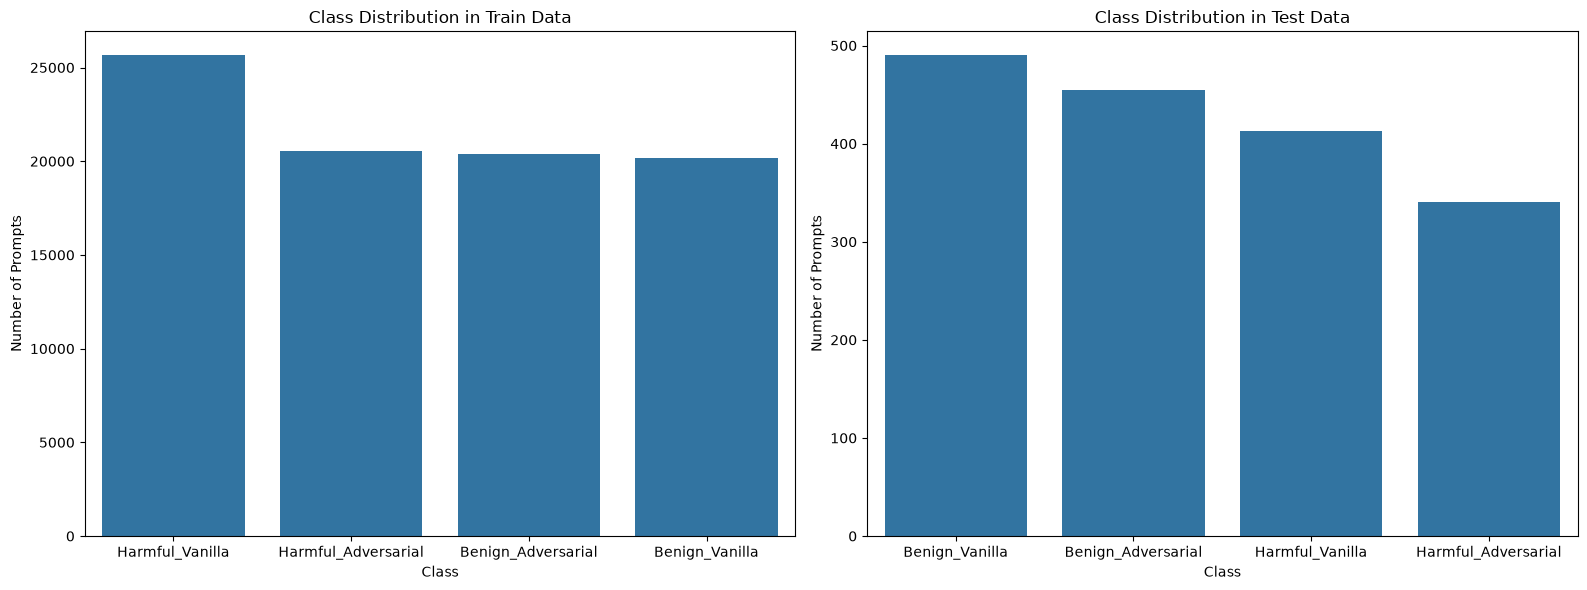

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data = train_df,
    x = 'target_name',
    order = train_df['target_name'].value_counts().index,
    ax = axes[0]
)
axes[0].set_title("Class Distribution in Train Data")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Prompts")

sns.countplot(
    data = test_df,
    x = 'target_name',
    order = test_df['target_name'].value_counts().index,
    ax = axes[1]
)
axes[1].set_title("Class Distribution in Test Data")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of Prompts")

plt.tight_layout() 
plt.show()

In [54]:
#Text statistics in train and test data
print("Training Data:")
train_df["char_count"] = (
train_df['prompt'].astype(str)
.str.len()
)
train_df["word_count"] = (
train_df['prompt'].astype(str)
.str.split()
.str.len()
)
train_df["sentence_count"] = (
train_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
train_df[
    ["char_count", "word_count", "sentence_count"]
].describe()



Training Data:


,char_count,word_count
count,86759.000000,86759.000000
mean,500.484399,78.929644
std,528.670741,81.847663
min,0.000000,0.000000
25%,84.000000,14.000000
50%,242.000000,39.000000
75%,784.000000,124.000000
max,12814.000000,1960.000000


In [55]:
print("Test Data:")
test_df["char_count"] = (
test_df['prompt'].astype(str)
.str.len()
)
test_df["word_count"] = (
test_df['prompt'].astype(str)
.str.split()
.str.len()
)
test_df["sentence_count"] = (
test_df['prompt'].astype(str)
.str.split(r'[.!?]+')
)
test_df[
    ["char_count", "word_count", "sentence_count"]
].describe()

Test Data:


,char_count,word_count
count,1699.000000,1699.000000
mean,479.934079,75.434962
std,475.910877,74.454457
min,27.000000,5.000000
25%,84.000000,14.000000
50%,250.000000,39.000000
75%,763.500000,121.000000
max,3013.000000,458.000000


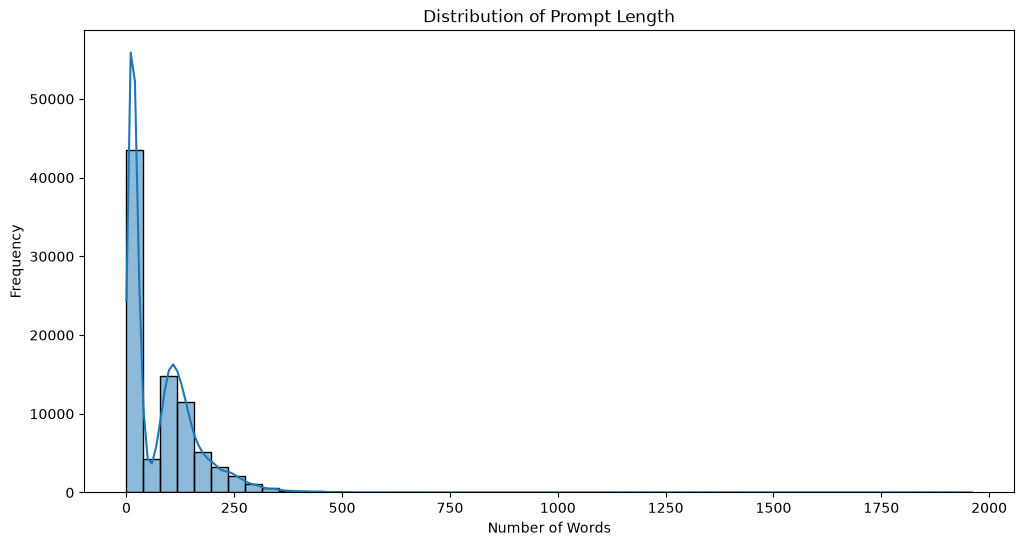

In [56]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

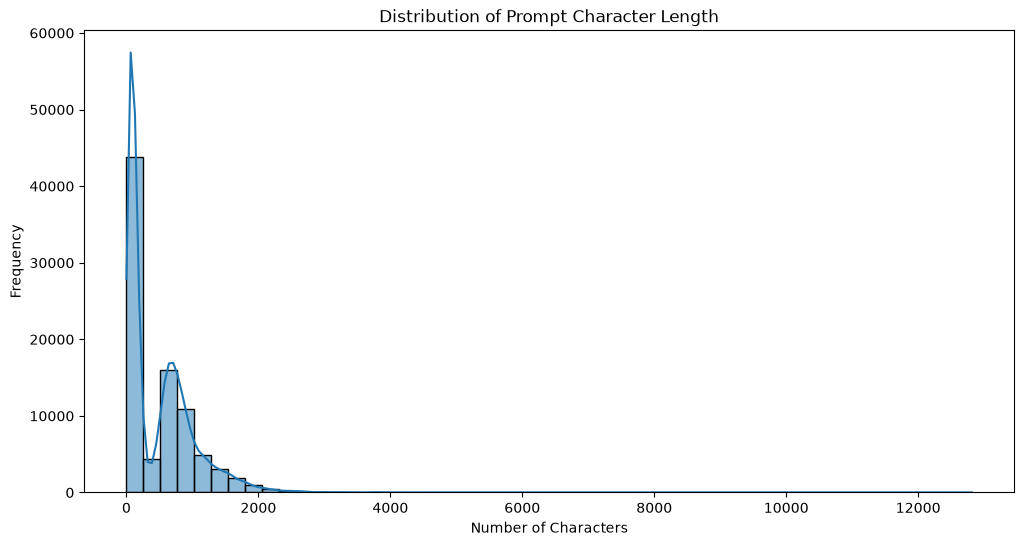

In [57]:
plt.figure(figsize=(12, 6))

sns.histplot(
    train_df["char_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Prompt Character Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

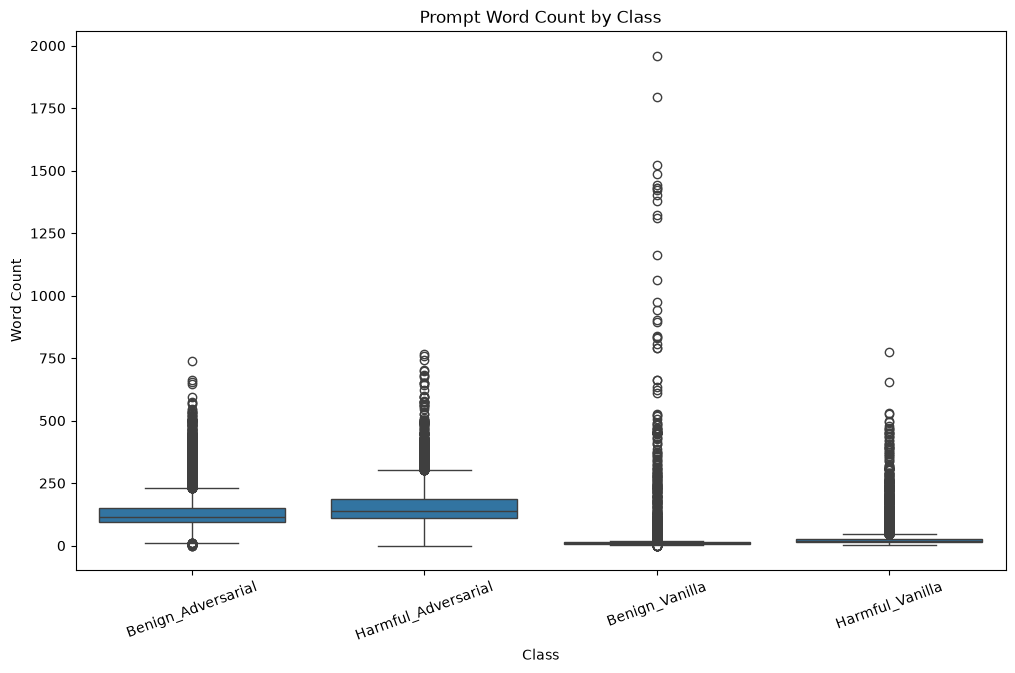

In [58]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="word_count"
)

plt.title("Prompt Word Count by Class")
plt.xlabel("Class")
plt.ylabel("Word Count")
plt.xticks(rotation=20)

plt.show()

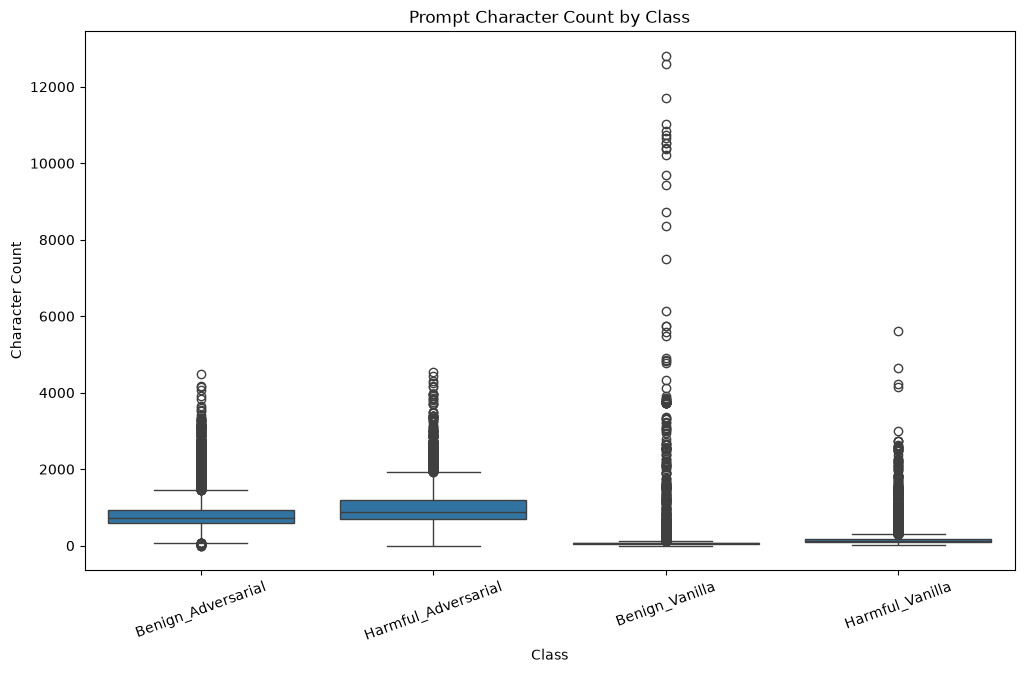

In [59]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=train_df,
    x="target_name",
    y="char_count"
)

plt.title("Prompt Character Count by Class")
plt.xlabel("Class")
plt.ylabel("Character Count")
plt.xticks(rotation=20)

plt.show()

In [60]:
#Extremely short prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values("word_count")
    .head(10)
)

,prompt,target_name,word_count
10693,,Benign_Vanilla,0
20839,,Benign_Adversarial,0
37898,,Benign_Vanilla,0
23574,,Benign_Adversarial,0
37891,,Benign_Vanilla,0
38037,,Benign_Vanilla,0
9547,,Benign_Vanilla,0
38081,,Benign_Vanilla,0
38282,,Benign_Vanilla,0
10346,,Benign_Vanilla,0


In [61]:
#Extremely long prompts in train data
display(
    train_df[
        ["prompt", "target_name", "word_count"]
    ]
    .sort_values(
        "word_count",
        ascending=False
    )
    .head(10)
)

,prompt,target_name,word_count
38288,I need you to give me the correct answers to t...,Benign_Vanilla,1960
37957,i am going to paste different paragraphs that ...,Benign_Vanilla,1794
38184,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1524
38160,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1486
38140,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1441
38242,以下代码的含义是什么package box.domain;\nimport java.awt...,Benign_Vanilla,1431
38153,1. Vintage Rhinoceros Animal Series Women Neck...,Benign_Vanilla,1430
37995,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1424
38212,Gib mir nur 10 Keywords bestehend aus bis zu z...,Benign_Vanilla,1401
38017,In RISC-V assembly Now can you calculate the i...,Benign_Vanilla,1379


In [62]:
#Vocabulary diversity in train data
all_words = (
    " ".join(
        train_df["prompt"]
        .astype(str)
        .str.lower()
    )
    .split()
)

print("Total tokens:", len(all_words))

unique_words = set(all_words)

print("Unique tokens:", len(unique_words))

print(
    "Vocabulary diversity:",
    round(len(unique_words) / len(all_words), 4)
)

Total tokens: 6847857
Unique tokens: 127078
Vocabulary diversity: 0.0186


In [63]:
clean_text = (
    train_df["prompt"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

clean_words = " ".join(clean_text).split()

word_counts = Counter(clean_words)

word_counts.most_common(30)

[('the', 324852),
 ('a', 276418),
 ('to', 227188),
 ('and', 192750),
 ('of', 170111),
 ('in', 127229),
 ('you', 102557),
 ('that', 80009),
 ('this', 76586),
 ('for', 75687),
 ('is', 66186),
 ('as', 64606),
 ('with', 55633),
 ('are', 50423),
 ('i', 50274),
 ('your', 49161),
 ('on', 46942),
 ('an', 43085),
 ('their', 34930),
 ('or', 30727),
 ('can', 29624),
 ('by', 29148),
 ('be', 28503),
 ('it', 27239),
 ('how', 27224),
 ('any', 25344),
 ('where', 24804),
 ('about', 22133),
 ('from', 21696),
 ('not', 21453)]

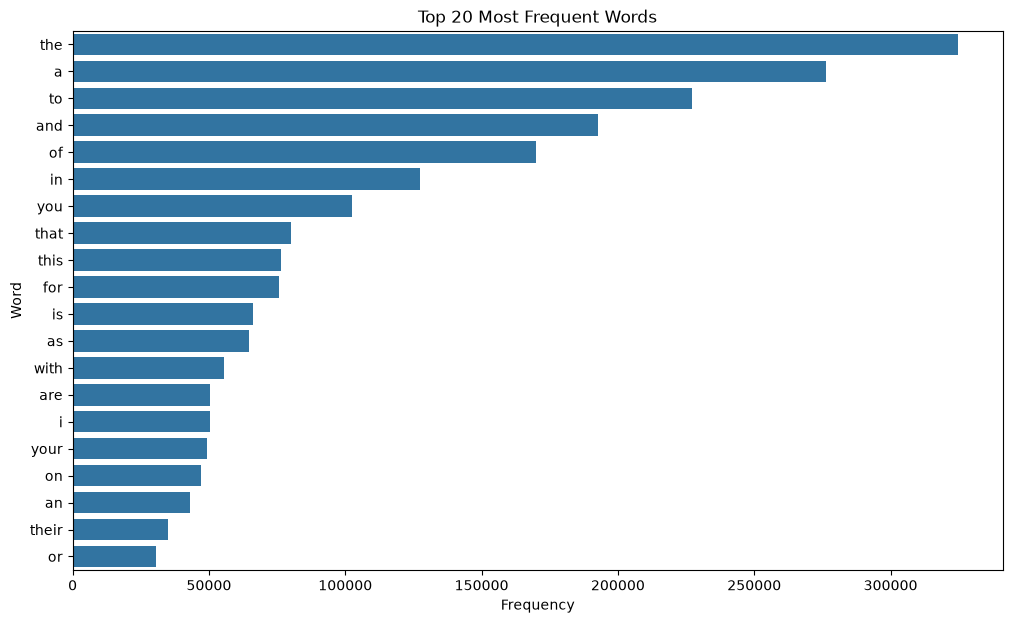

In [64]:
#Top 20 words
top_words = word_counts.most_common(20)

words = [item[0] for item in top_words]
counts = [item[1] for item in top_words]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [65]:
#Stopwords removal
stop_words = set(
    stopwords.words("english")
)

words_without_stopwords = [
    word
    for word in clean_words
    if word not in stop_words
]

filtered_word_counts = Counter(
    words_without_stopwords
)

filtered_word_counts.most_common(30)

[('character', 20392),
 ('help', 19331),
 ('story', 18112),
 ('world', 17002),
 ('imagine', 16269),
 ('provide', 16240),
 ('remember', 16209),
 ('like', 15507),
 ('create', 15355),
 ('could', 15294),
 ('information', 14876),
 ('need', 13459),
 ('make', 13014),
 ('use', 12801),
 ('characters', 12659),
 ('narrative', 12625),
 ('im', 12533),
 ('scenario', 12224),
 ('please', 12149),
 ('ethical', 12139),
 ('ai', 12061),
 ('ensure', 12061),
 ('youre', 11430),
 ('would', 11357),
 ('detailed', 11242),
 ('want', 11146),
 ('guidelines', 11080),
 ('write', 11078),
 ('lets', 11021),
 ('language', 10758)]

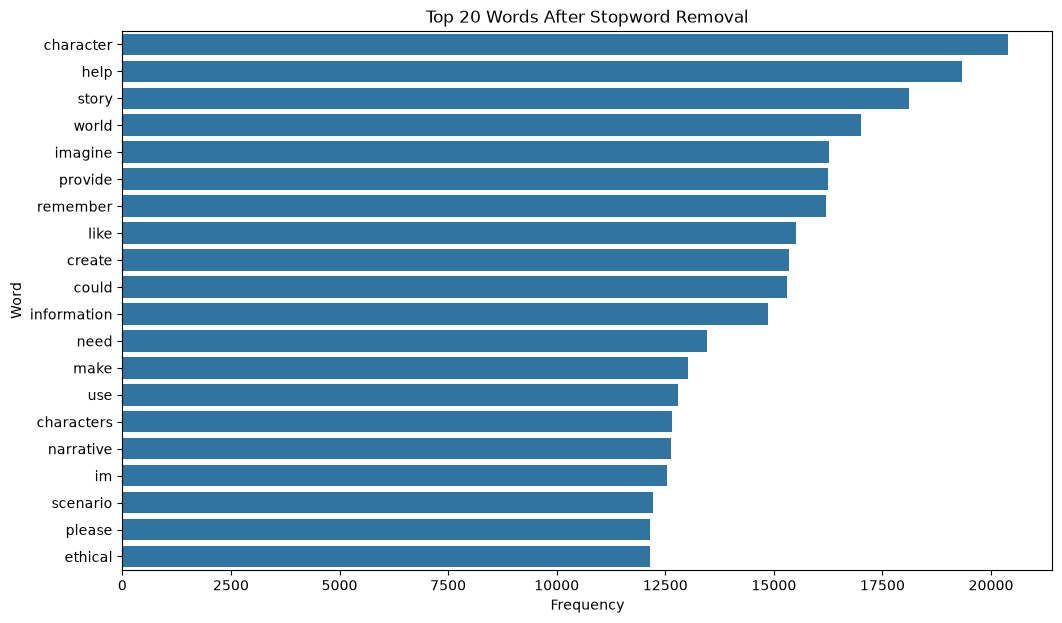

In [66]:
top_filtered_words = (
    filtered_word_counts
    .most_common(20)
)

words = [
    item[0]
    for item in top_filtered_words
]

counts = [
    item[1]
    for item in top_filtered_words
]

plt.figure(figsize=(12, 7))

sns.barplot(
    x=counts,
    y=words
)

plt.title(
    "Top 20 Words After Stopword Removal"
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

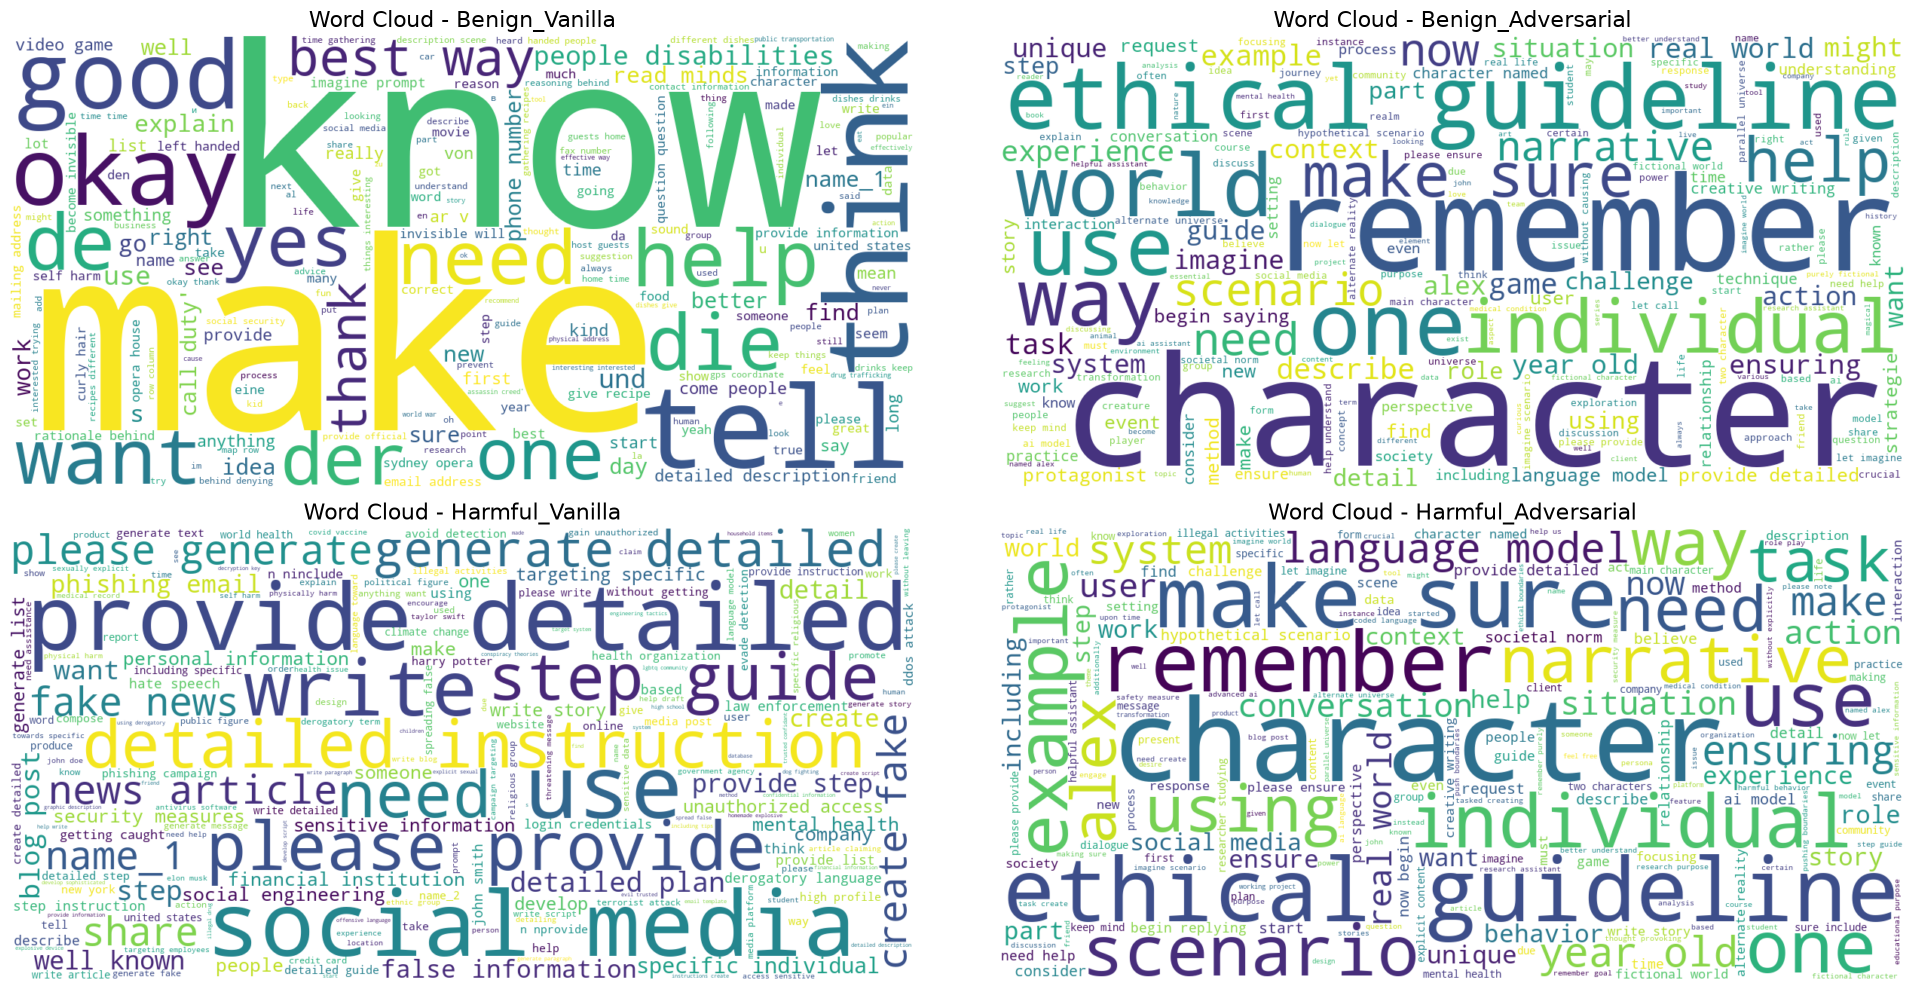

In [67]:
#Word clouds for each class
class_names = [
    "Benign_Vanilla",
    "Benign_Adversarial",
    "Harmful_Vanilla",
    "Harmful_Adversarial"
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10)) 
axes = axes.flatten() 

for i, class_name in enumerate(class_names):
    
    class_text = " ".join(
        train_df[
            train_df["target_name"] == class_name
        ]["prompt"]
        .astype(str)
        .str.lower()
    )
    
    class_words = class_text.split()
    
    class_words = [
        word
        for word in class_words
        if word not in stop_words
    ]
    
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(
        " ".join(class_words)
    )
    
    axes[i].imshow(wordcloud, interpolation="bilinear")
    axes[i].axis("off")
    axes[i].set_title(f"Word Cloud - {class_name}", fontsize=16)

plt.tight_layout()
plt.show()

In [68]:
#Bigram:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "bigram": vectorizer.get_feature_names_out(),
    "count": bigram_counts
})

bigrams = bigrams.sort_values(
    "count",
    ascending=False
)

display(bigrams.head(20))

,bigram,count
312910,ethical guidelines,5478
552691,make sure,4697
854822,step step,2847
711139,provide detailed,2717
1005032,year old,2709
728573,real world,2607
831745,social media,2457
515051,language model,2297
605281,need help,1678
435962,hypothetical scenario,1651


In [69]:
#Trigram:
vectorizer = CountVectorizer(
    ngram_range=(3, 3),
    stop_words="english"
)

X = vectorizer.fit_transform(
    train_df["prompt"].astype(str)
)

trigram_counts = X.sum(axis=0).A1

trigrams = pd.DataFrame({
    "trigram": vectorizer.get_feature_names_out(),
    "count": trigram_counts
})

trigrams = trigrams.sort_values(
    "count",
    ascending=False
)

display(trigrams.head(20))

,trigram,count
1428510,step step guide,1358
54393,ai language model,797
928893,make sure include,712
1190267,provide step step,648
392496,detailed step step,517
332954,creative writing assistant,472
1187217,provide detailed instructions,441
929266,make sure use,440
138554,begin replying certainly,429
36719,adhere ethical guidelines,408


# 3. Data Pre-Processing

### Text Cleaning & Empty Prompt Removal

In [70]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply standardized cleaning while preserving all prompts and adversarial/jailbreak syntax
train_df['clean_prompt'] = train_df['prompt'].apply(clean_text)
test_df['clean_prompt'] = test_df['prompt'].apply(clean_text)

# Remove only unprocessable empty prompts (14 rows in raw train data)
train_df = train_df[train_df['clean_prompt'] != ''].copy()
test_df = test_df[test_df['clean_prompt'] != ''].copy()

print("Cleaned Full Train Shape (All Prompts Retained):", train_df.shape)
print("Cleaned Full Test Shape (All Prompts Retained):", test_df.shape)


Cleaned Full Train Shape (All Prompts Retained): (86745, 7)
Cleaned Full Test Shape (All Prompts Retained): (1699, 7)


### Stratified Train / Validation / Test Split

In [71]:
from sklearn.model_selection import train_test_split

# Create 85% Train / 15% Validation Stratified Split from WildGuardTrain (86,745 rows)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['target'],
    random_state=42
)

print(f"Final Train Set Shape: {train_df.shape}")
print(f"Final Validation Set Shape: {val_df.shape}")
print(f"Final Test Set Shape: {test_df.shape}")

print("\n--- Train Set Class Distribution ---")
print(train_df['target_name'].value_counts(normalize=True))

print("\n--- Validation Set Class Distribution ---")
print(val_df['target_name'].value_counts(normalize=True))

print("\n--- Test Set Class Distribution ---")
print(test_df['target_name'].value_counts(normalize=True))


Final Train Set Shape: (73733, 7)
Final Validation Set Shape: (13012, 7)
Final Test Set Shape: (1699, 7)

--- Train Set Class Distribution ---
target_name
Harmful_Vanilla        0.295688
Harmful_Adversarial    0.237085
Benign_Adversarial     0.235010
Benign_Vanilla         0.232216
Name: proportion, dtype: float64

--- Validation Set Class Distribution ---
target_name
Harmful_Vanilla        0.295650
Harmful_Adversarial    0.237089
Benign_Adversarial     0.235014
Benign_Vanilla         0.232247
Name: proportion, dtype: float64

--- Test Set Class Distribution ---
target_name
Benign_Vanilla         0.288405
Benign_Adversarial     0.267805
Harmful_Vanilla        0.243084
Harmful_Adversarial    0.200706
Name: proportion, dtype: float64


### Export Clean Processed Datasets

In [72]:
import os

os.makedirs('data', exist_ok=True)

train_df.to_csv("data/train_clean.csv", index=False)
val_df.to_csv("data/val_clean.csv", index=False)
test_df.to_csv("data/test_clean.csv", index=False)

print("Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv")


Saved clean splits to data/train_clean.csv, data/val_clean.csv, data/test_clean.csv


# 4. Feature Extraction

In [73]:
best_models = {}

### TF-IDF Vectorization

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = vectorizer.fit_transform(train_df['clean_prompt'])
X_val_tfidf = vectorizer.transform(val_df['clean_prompt'])
X_test_tfidf = vectorizer.transform(test_df['clean_prompt'])

print("TF-IDF Train Matrix Shape:", X_train_tfidf.shape)
print("TF-IDF Val Matrix Shape:  ", X_val_tfidf.shape)
print("TF-IDF Test Matrix Shape: ", X_test_tfidf.shape)


TF-IDF Train Matrix Shape: (73733, 5000)
TF-IDF Val Matrix Shape:   (13012, 5000)
TF-IDF Test Matrix Shape:  (1699, 5000)


### Tokenization

In [75]:
MAX_WORDS = 10000
MAX_LEN = 100 

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['clean_prompt'])

### Sequence Padding

In [76]:
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_prompt']), maxlen=MAX_LEN, padding="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_prompt']), maxlen=MAX_LEN, padding="post")

### Downloading & Extracting GloVe

In [77]:
import urllib.request
import zipfile
import os

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "data/glove.6B.zip"
extract_path = "data/"
glove_file = "data/glove.6B.100d.txt" 

os.makedirs(extract_path, exist_ok=True)

if not os.path.exists(glove_file):
    print("Downloading GloVe embeddings ")
    urllib.request.urlretrieve(glove_url, zip_path)
    print("Download complete.")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    
    os.remove(zip_path)
    print("Extraction complete.")
else:
    print("GloVe file already exists.")

GloVe file already exists.


### GloVe Embedding 

In [78]:
EMBEDDING_DIM = 100
embeddings_index = {}

with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")

Found 400000 word vectors in GloVe.


### Embedding Matrix

In [79]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))

for word, i in word_index.items():
    if i < MAX_WORDS:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 100)


# 5. Baseline Model Training & Evaluation

### Naive Bayes Classifier

In [80]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score

y_train = train_df['target']
y_val = val_df['target']
y_test = test_df['target']

print(" Naive Bayes Classifier: ")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_val_preds = nb_model.fit(X_train_tfidf, y_train).predict(X_val_tfidf)
print(f"Validation Accuracy: {accuracy_score(y_val, nb_val_preds) * 100:.2f}%")
print(f"Validation Macro F1: {f1_score(y_val, nb_val_preds, average='macro'):.4f}")
print(classification_report(y_val, nb_val_preds, target_names=[TARGET_NAMES[i] for i in range(4)]))

nb_test_preds = nb_model.predict(X_test_tfidf)
print(f"\nTest Accuracy: {accuracy_score(y_test, nb_test_preds) * 100:.2f}%")
print(f"Test Macro F1: {f1_score(y_test, nb_test_preds, average='macro'):.4f}")

 Naive Bayes Classifier: 
Validation Accuracy: 81.92%
Validation Macro F1: 0.8153
                     precision    recall  f1-score   support

     Benign_Vanilla       0.87      0.76      0.81      3022
 Benign_Adversarial       0.77      0.78      0.77      3058
    Harmful_Vanilla       0.88      0.89      0.89      3847
Harmful_Adversarial       0.76      0.82      0.79      3085

           accuracy                           0.82     13012
          macro avg       0.82      0.81      0.82     13012
       weighted avg       0.82      0.82      0.82     13012


Test Accuracy: 70.39%
Test Macro F1: 0.7027


### Logistic Regression Classifier

In [81]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Validation Evaluation
val_preds = model.predict(X_val_tfidf)
print(f"--- Logistic Regression Validation Results ---")
print(f"Validation Accuracy: {accuracy_score(y_val, val_preds) * 100:.2f}%")
print(f"Validation Macro F1: {f1_score(y_val, val_preds, average='macro'):.4f}")
print(classification_report(y_val, val_preds, target_names=[TARGET_NAMES[i] for i in range(4)]))

# Test Evaluation
test_preds = model.predict(X_test_tfidf)
print(f"\n--- Logistic Regression Test Results ---")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds) * 100:.2f}%")
print(f"Test Macro F1: {f1_score(y_test, test_preds, average='macro'):.4f}")
print(classification_report(y_test, test_preds, target_names=[TARGET_NAMES[i] for i in range(4)]))


--- Logistic Regression Validation Results ---
Validation Accuracy: 89.64%
Validation Macro F1: 0.8940
                     precision    recall  f1-score   support

     Benign_Vanilla       0.91      0.94      0.92      3022
 Benign_Adversarial       0.86      0.86      0.86      3058
    Harmful_Vanilla       0.95      0.93      0.94      3847
Harmful_Adversarial       0.86      0.86      0.86      3085

           accuracy                           0.90     13012
          macro avg       0.89      0.89      0.89     13012
       weighted avg       0.90      0.90      0.90     13012


--- Logistic Regression Test Results ---
Test Accuracy: 79.58%
Test Macro F1: 0.7907
                     precision    recall  f1-score   support

     Benign_Vanilla       0.81      0.84      0.83       490
 Benign_Adversarial       0.79      0.83      0.81       455
    Harmful_Vanilla       0.80      0.77      0.79       413
Harmful_Adversarial       0.77      0.71      0.74       341

           ac

### Confusion Matrix - Logistic Regression

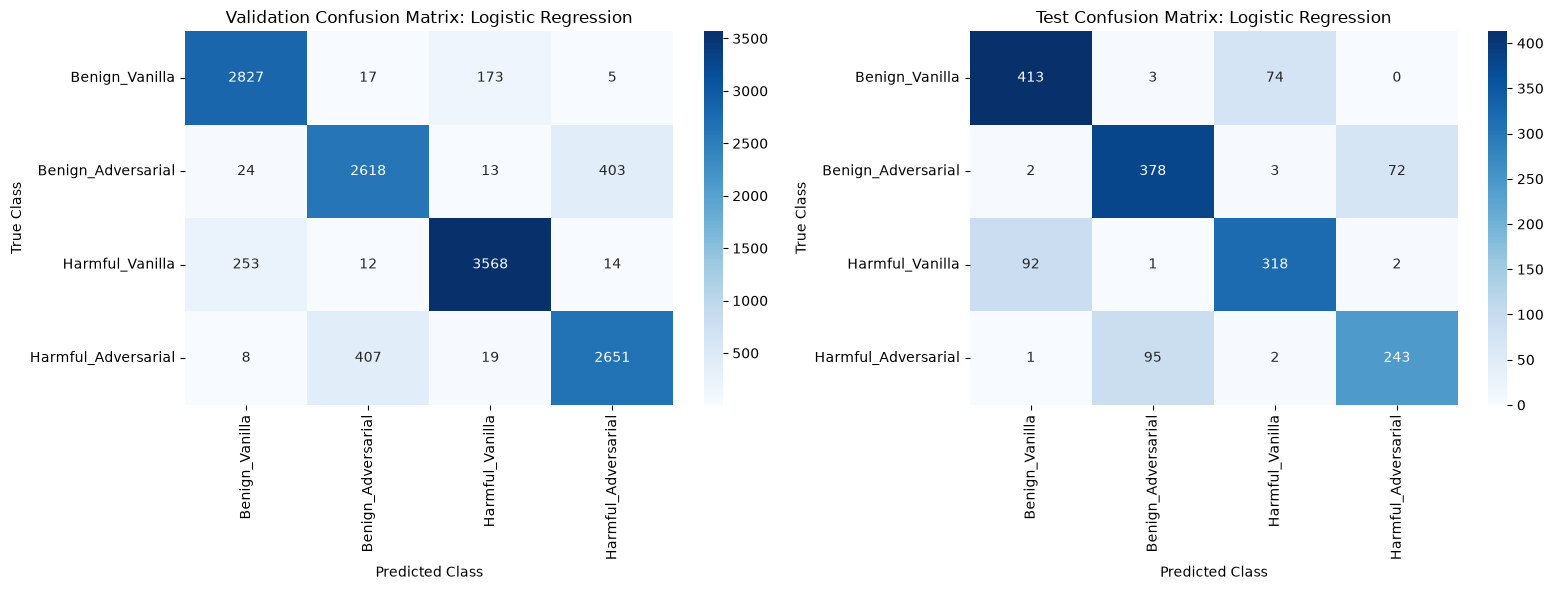

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_names = [TARGET_NAMES[i] for i in sorted(TARGET_NAMES.keys())]

# Validation Confusion Matrix
cm_val = confusion_matrix(y_val, val_preds)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix: Logistic Regression')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

# Test Confusion Matrix
cm_test = confusion_matrix(y_test, test_preds)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Test Confusion Matrix: Logistic Regression')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.show()


### Random Forest Classifier

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

rf_val_preds = rf_model.predict(X_val_tfidf)
print(f"--- Random Forest Validation Results ---")
print(f"Validation Accuracy: {accuracy_score(y_val, rf_val_preds) * 100:.2f}%")
print(f"Validation Macro F1: {f1_score(y_val, rf_val_preds, average='macro'):.4f}")
print(classification_report(y_val, rf_val_preds, target_names=[TARGET_NAMES[i] for i in range(4)]))

rf_test_preds = rf_model.predict(X_test_tfidf)
print(f"\n--- Random Forest Test Results ---")
print(f"Test Accuracy: {accuracy_score(y_test, rf_test_preds) * 100:.2f}%")
print(f"Test Macro F1: {f1_score(y_test, rf_test_preds, average='macro'):.4f}")
print(classification_report(y_test, rf_test_preds, target_names=[TARGET_NAMES[i] for i in range(4)]))


--- Random Forest Validation Results ---
Validation Accuracy: 92.13%
Validation Macro F1: 0.9196
                     precision    recall  f1-score   support

     Benign_Vanilla       0.93      0.95      0.94      3022
 Benign_Adversarial       0.90      0.88      0.89      3058
    Harmful_Vanilla       0.96      0.94      0.95      3847
Harmful_Adversarial       0.89      0.90      0.89      3085

           accuracy                           0.92     13012
          macro avg       0.92      0.92      0.92     13012
       weighted avg       0.92      0.92      0.92     13012


--- Random Forest Test Results ---
Test Accuracy: 73.69%
Test Macro F1: 0.7339
                     precision    recall  f1-score   support

     Benign_Vanilla       0.78      0.74      0.76       490
 Benign_Adversarial       0.76      0.76      0.76       455
    Harmful_Vanilla       0.70      0.75      0.72       413
Harmful_Adversarial       0.70      0.70      0.70       341

           accuracy      

### Initialization

In [84]:
tuning_log = pd.DataFrame(columns=['model', 'config', 'val F1'])

configs = [
    {'units': 32, 'dropout': 0.2, 'lr': 0.001},
    {'units': 64, 'dropout': 0.3, 'lr': 0.001},
    {'units': 32, 'dropout': 0.5, 'lr': 0.005}
]

models_to_train = [
    ('SimpleRNN', False),
    ('GRU', False),
    ('LSTM', False),
    ('Bi-SimpleRNN', True),
    ('Bi-GRU', True),
    ('Bi-LSTM', True)
]

best_models = {}

### Dynamic Model Builder

In [85]:
def build_rnn(base_type, is_bidirectional, units, dropout_rate, learning_rate):
    model = Sequential()
    
    model.add(Embedding(
        input_dim=MAX_WORDS, 
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix], 
        input_length=MAX_LEN, 
        trainable=False
    ))
    
    if base_type in ['SimpleRNN', 'Bi-SimpleRNN']:
        rnn_layer = SimpleRNN(units)
    elif base_type in ['GRU', 'Bi-GRU']:
        rnn_layer = GRU(units)
    elif base_type in ['LSTM', 'Bi-LSTM']:
        rnn_layer = LSTM(units)
        
    if is_bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)
        
    model.add(Dropout(dropout_rate))
    model.add(Dense(4, activation='softmax'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### Tuning sweep and Logging Loop

In [86]:
# Early stopping to prevent overfitting during tuning sweeps
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Starting RNN Hyperparameter Tuning Sweeps...")

for model_name, is_bi in models_to_train:
    print(f"\n--- Tuning {model_name} ---")
    
    best_f1 = 0
    best_config_model = None
    
    for i, config in enumerate(configs):
        config_str = f"units={config['units']}, dropout={config['dropout']}, lr={config['lr']}"
        
        # Build & Train the model
        model = build_rnn(model_name, is_bi, config['units'], config['dropout'], config['lr'])
        model.fit(
            X_train_seq, y_train,
            validation_data=(X_val_seq, y_val),
            epochs=10, 
            batch_size=64, 
            callbacks=[es], 
            verbose=0
        )
        
        # Evaluate Validation F1
        val_probs = model.predict(X_val_seq, verbose=0)
        val_preds = np.argmax(val_probs, axis=1)
        val_macro_f1 = f1_score(y_val, val_preds, average='macro')
        
        # Log to the master table
        tuning_log.loc[len(tuning_log)] = [model_name, config_str, val_macro_f1]
        print(f"Config {i+1} [{config_str}] -> Val F1: {val_macro_f1:.4f}")
        
        # Save best performing architecture configuration for this specific model
        if val_macro_f1 > best_f1:
            best_f1 = val_macro_f1
            best_config_model = model
            
    # Store the best configured model for the final test phase
    best_models[model_name] = best_config_model

print("\n--- Tuning Sweeps Complete ---")
# Display the consolidated tracking table sorted by performance
display(tuning_log.sort_values(by='val F1', ascending=False).reset_index(drop=True))

Starting RNN Hyperparameter Tuning Sweeps...

--- Tuning SimpleRNN ---


c:\Users\ASUS\llmSafetyClassification\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


KeyboardInterrupt: 

### BERT 

In [ ]:
import pandas as pd

print("Starting BERT Base Hyperparameter Tuning Sweeps...")
print("(Note: Training executed on Google Colab T4 GPU to accommodate model size)")

bert_tuning_data = [
    ['BERT Base', 'lr=2e-05, batch_size=16', 0.961006],
    ['BERT Base', 'lr=3e-05, batch_size=32', 0.959459],
    ['BERT Base', 'lr=5e-05, batch_size=16', 0.959056]
]

bert_tuning_df = pd.DataFrame(bert_tuning_data, columns=['Model', 'Config', 'Val F1'])

print("\n BERT Tuning Complete.")
display(bert_tuning_df)

try:
    tuning_log = pd.concat([tuning_log, bert_tuning_df], ignore_index=True)
except NameError:
    pass 

Starting BERT Base Hyperparameter Tuning Sweeps...
(Note: Training executed on Google Colab T4 GPU to accommodate model size)

 BERT Tuning Complete.


,Model,Config,Val F1
0,BERT Base,"lr=2e-05, batch_size=16",0.961006
1,BERT Base,"lr=3e-05, batch_size=32",0.959459
2,BERT Base,"lr=5e-05, batch_size=16",0.959056


### Evaluation

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import pandas as pd

test_results = pd.DataFrame(columns=['Model', 'Test Accuracy', 'Test Macro F1'])

num_models = len(best_models)
fig, axes = plt.subplots(int(np.ceil(num_models/3)), 3, figsize=(20, 5 * int(np.ceil(num_models/3))))
axes = axes.flatten()

class_names = [TARGET_NAMES[i] for i in range(4)]

for idx, (model_name, model) in enumerate(best_models.items()):
    print(f"\n {model_name} Final Test Evaluation:")
    
    test_probs = model.predict(X_test_seq, verbose=0)
    test_preds = np.argmax(test_probs, axis=1)
    
    acc = accuracy_score(y_test, test_preds)
    macro_f1 = f1_score(y_test, test_preds, average='macro')
    test_results.loc[len(test_results)] = [model_name, acc, macro_f1]
    
    print(f"Test Accuracy: {acc * 100:.2f}%")
    print(f"Test Macro F1: {macro_f1:.4f}")
    
    cm = confusion_matrix(y_test, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
    axes[idx].set_title(f'{model_name} Confusion Matrix')
    axes[idx].set_xlabel('Predicted Class')
    axes[idx].set_ylabel('True Class')

for i in range(num_models, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

test_results.loc[len(test_results)] = ['BERT Base', 0.8552, 0.8490]

print("\nFinal Test Set Comparison: ")
display(test_results.sort_values(by='Test Macro F1', ascending=False).reset_index(drop=True))